# Max-Flow Optimization for a Gas Network with QAOA

This notebook demonstrates how to solve a gas-network max-flow problem using a quantum optimization workflow based on QAOA.

The goal is: **maximize the total gas inflow delivered to the customer nodes** while respecting the physical and operational behavior of the network.

The network contains one supply node, intermediate junction nodes, and three customer nodes. The optimizer searches over possible pressure levels at the non-source nodes. From those pressure levels, the notebook estimates the resulting pipe flows and ranks the best sampled solutions.

The notebook is organized as follows:

1. Define and visualize the directed gas network.
2. Encode pressure decision variables using discretization.
3. Convert physical pipe data into flow coefficients using the Panhandle-B gas-flow formula.
4. Build the optimization objective and constraints.
5. Normalize the objective and penalties so they can be used inside the QAOA cost layer.
6. Build and run the QAOA circuit.
7. Post-process the sampled quantum results into customer flows, feasibility labels, and gas velocity checks.

## Imports and setup

In [1]:
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.optimize import minimize

from classiq import *

## 1. Problem formulation

Let $G=(N,E)$ be a directed gas network with source node $s$, customer nodes $C \subset N$, edge flows $y_{ij} \ge 0$, and node pressures $p_i$. It is convenient to work with the squared-pressure variable

$$
\pi_i = p_i^2.
$$

For a directed edge $(i,j) \in E$, we use the generalized Panhandle-B relation

$$
y_{ij}[\mathrm{kSm^3/h}] = K_{ij}^{\mathrm{phys}} \, (\pi_i - \pi_j)^{\alpha_{\mathrm{PB}}},
\qquad \alpha_{\mathrm{PB}} > 0,
$$

$$
K_{ij}^{\mathrm{phys}}
=
C \cdot E
\cdot
\left(\frac{T_b}{P_b}\right)^{2\alpha_{\mathrm{PB}}}
\cdot
D^{2.53}
\cdot
\left(
\frac{1}
{G^{0.961} \cdot T_f \cdot L \cdot Z}
\right)^{\alpha_{\mathrm{PB}}}
$$



with the direction condition $\pi_i \ge \pi_j$.

The continuous max-flow problem is

$$
\max_{\pi}\;
\sum_{(i,c)\in E,\; c\in C} w_{c}y_{ic},
$$

subject to flow conservation at every internal node,

$$
\sum_{(i,j)\in E} y_{ij} - \sum_{(j,k)\in E} y_{jk} = 0,
\qquad \forall j\in N\setminus(\{s\}\cup C),
$$


pressure bounds,

$$
\pi_i^{\min} \le \pi_i \le \pi_i^{\max},
\qquad \forall i\in N,
$$

and directed flow consistency,

$$
\pi_i \ge \pi_j,
\qquad \forall (i,j)\in E.
$$



## 2. Gas Network Definition

The gas network is represented as a directed graph.

- `S1` is the source node, where gas enters the network.
- `BVS1` and `BVS2` are intermediate nodes where flow must be conserved.
- `C1`, `C2`, and `C3` are customer nodes, where we want to maximize delivered gas.

The directed pipes are:

- `S1 → BVS1`
- `BVS1 → C1`
- `BVS1 → BVS2`
- `BVS2 → C3`
- `BVS2 → C2`


In [2]:
# =========================================================
# 1) Utilities
# =========================================================


def plot_max_flow_graph(
    graph,
    pos,
    source="S1",
    sinks=None,
    edge_label_key="label",
    figsize=(10, 4),
):
    if sinks is None:
        sinks = []

    plt.figure(figsize=figsize)

    node_colors = []
    for node in graph.nodes():
        if node == source:
            node_colors.append("tab:red")  # source node color
        elif node in sinks:
            node_colors.append("tab:green")  # customer nodes color
        else:
            node_colors.append("lightblue")  # intermediate nodes color

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=900,
        node_color=node_colors,
        edgecolors="black",
    )

    nx.draw_networkx_labels(graph, pos)
    nx.draw_networkx_edges(graph, pos, arrows=True, arrowsize=18)

    edge_labels = {
        (u, v): d.get(edge_label_key, "") for (u, v, d) in graph.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=10,
        label_pos=0.55,
    )

    plt.title("Graph visualization")
    plt.axis("off")
    plt.show()


def create_max_flow_graph():
    graph = nx.DiGraph()
    nodes = ["S1", "BVS1", "BVS2", "C1", "C2", "C3"]
    graph.add_nodes_from(nodes)

    edges_with_data = [
        ("S1", "BVS1", {"label": "L1"}),
        ("BVS1", "C1", {"label": "L2"}),
        ("BVS1", "BVS2", {"label": "L3"}),
        ("BVS2", "C3", {"label": "L4"}),
        ("BVS2", "C2", {"label": "L5"}),
    ]

    graph.add_edges_from(edges_with_data)

    ordered_edges = [(u, v) for (u, v, _) in edges_with_data]

    return graph, nodes, ordered_edges

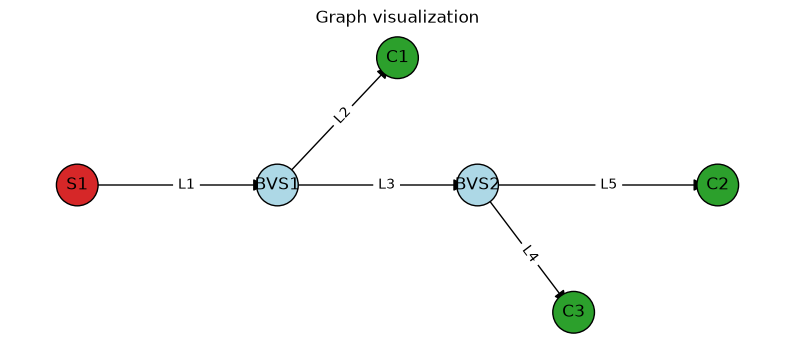

In [3]:
# =========================================================
# 2) Graph definition
# =========================================================


graph, nodes, ordered_edges = create_max_flow_graph()

source = "S1"
sinks = ["C1", "C2", "C3"]

pos = {
    "S1": (0.0, 0.0),
    "BVS1": (2.5, 0.0),
    "BVS2": (5.0, 0.0),
    "C2": (8.0, 0.0),
    "C1": (4.0, 1.6),
    "C3": (6.2, -1.6),
}

plot_max_flow_graph(graph, pos, source=source, sinks=sinks)

## 3. Decision Variables

The optimizer does not directly choose continuous pipe flows. Instead, it chooses discrete pressure-level variables for every node except the source.

Each decision node is represented by `num_qbits = 3` qubits, which means each node can take one of 8 discrete values: `0` through `7`.

The source node pressure is fixed, so it is not treated as a decision variable. The optimization therefore searches over pressure levels for:

- `BVS1`
- `BVS2`
- `C1`
- `C2`
- `C3`

Customer weights are also defined here. In this version, all customers have equal weight, so maximizing customer inflow means maximizing the total delivered flow to `C1`, `C2`, and `C3` equally.


In [4]:
# =========================================================
# 3) Decision-variable and model configuration
# =========================================================

# Decision variables: q for all nodes except source
decision_nodes = [n for n in nodes if n != source]
num_decision_nodes = len(decision_nodes)
dec_node_to_idx = {n: i for i, n in enumerate(decision_nodes)}

num_qbits = 3
q_max = (1 << num_qbits) - 1  # 7 for 3 qubits

customer_weights = {"C1": 1.0, "C2": 2.0, "C3": 3.0}

## 4. Physical Preprocessing: Pipe Flow Coefficients

This section converts the physical pipe data into coefficients that the optimization model can use.

Each pipe has its own physical parameters, such as length, internal diameter, gas temperature, compressibility factor, and efficiency. These parameters are converted into a pipe-specific coefficient `K_phys`.

The notebook also defines the physical pressure range:

- Maximum pressure comes from the source pressure.
- Minimum pressure comes from the required minimum customer pressure.


In [5]:
# =========================================================
# 4) Physical preprocess:
#    - exact Panhandle-B K_phys
#    - pi(q) = a + b*q with PHYSICAL pi bounds
# =========================================================

source_barg = 70.0
min_customer_barg = 30.0


BASE_PRESSURE_BAR_ABS = 1.01325
BASE_TEMPERATURE_C = 15.0
GAS_SPECIFIC_GRAVITY = 0.60
COMPRESSIBILITY_FACTOR_Z = 0.90
PIPE_EFFICIENCY_FACTOR = 0.92

pipe_params = {
    ("S1", "BVS1"): {
        "E": PIPE_EFFICIENCY_FACTOR,
        "Tb_C": BASE_TEMPERATURE_C,
        "Pb_bara": BASE_PRESSURE_BAR_ABS,
        "G": GAS_SPECIFIC_GRAVITY,
        "Z": COMPRESSIBILITY_FACTOR_Z,
        "T_C": 20.0,
        "L_km": 70.0,
        "ID_in": 23.0,
    },
    ("BVS1", "C1"): {
        "E": PIPE_EFFICIENCY_FACTOR,
        "Tb_C": BASE_TEMPERATURE_C,
        "Pb_bara": BASE_PRESSURE_BAR_ABS,
        "G": GAS_SPECIFIC_GRAVITY,
        "Z": COMPRESSIBILITY_FACTOR_Z,
        "T_C": 0.0,
        "L_km": 10.0,
        "ID_in": 6.0,
    },
    ("BVS1", "BVS2"): {
        "E": PIPE_EFFICIENCY_FACTOR,
        "Tb_C": BASE_TEMPERATURE_C,
        "Pb_bara": BASE_PRESSURE_BAR_ABS,
        "G": GAS_SPECIFIC_GRAVITY,
        "Z": COMPRESSIBILITY_FACTOR_Z,
        "T_C": 20.0,
        "L_km": 20.0,
        "ID_in": 23.0,
    },
    ("BVS2", "C3"): {
        "E": PIPE_EFFICIENCY_FACTOR,
        "Tb_C": BASE_TEMPERATURE_C,
        "Pb_bara": BASE_PRESSURE_BAR_ABS,
        "G": GAS_SPECIFIC_GRAVITY,
        "Z": COMPRESSIBILITY_FACTOR_Z,
        "T_C": 5.0,
        "L_km": 30.0,
        "ID_in": 11.9,
    },
    ("BVS2", "C2"): {
        "E": PIPE_EFFICIENCY_FACTOR,
        "Tb_C": BASE_TEMPERATURE_C,
        "Pb_bara": BASE_PRESSURE_BAR_ABS,
        "G": GAS_SPECIFIC_GRAVITY,
        "Z": COMPRESSIBILITY_FACTOR_Z,
        "T_C": 20.0,
        "L_km": 50.0,
        "ID_in": 17.0,
    },
}

BAR_TO_PSI = 14.5037738
KM_TO_MILE = 0.621371
FT3_TO_M3 = 0.028316846592
P_ATM_BAR = 1.01325
EXP_base = 1.02
EXP_n = 2.53
EXP_x = 0.961
PANHANDLE_EXP = 0.51
C_PB = 30.7083


def celsius_to_rankine(temp_c: float) -> float:
    return (temp_c + 273.15) * 9.0 / 5.0


def panhandle_b_k_kSm3h_per_bar(E, Tb_C, Pb_bara, G, Z, T_C, L_km, ID_in):
    """
    Returns K_phys for:

        Q[kSm3/h] = K_phys * (P1^2 - P2^2)**0.51

    where pressure is in bar absolute.
    """
    Tb_R = celsius_to_rankine(Tb_C)
    Tf_R = celsius_to_rankine(T_C)
    Pb_psia = Pb_bara * BAR_TO_PSI
    L_mi = L_km * KM_TO_MILE
    D_in = ID_in

    K_cfh_per_psi = (
        C_PB
        * E
        * (Tb_R / Pb_psia) ** EXP_base
        * (D_in**EXP_n)
        * (1.0 / ((G**EXP_x) * Tf_R * L_mi * Z)) ** PANHANDLE_EXP
    )

    K_m3h_per_psi = K_cfh_per_psi * FT3_TO_M3
    K_m3h_per_bar = K_m3h_per_psi * (BAR_TO_PSI ** (2.0 * PANHANDLE_EXP))
    return K_m3h_per_bar / 1000.0


# Physical pressure bounds in bara
P_MAX = source_barg + P_ATM_BAR
P_MIN = min_customer_barg + P_ATM_BAR

# Physical pi bounds
PI_MAX = P_MAX**2
PI_MIN = P_MIN**2
PI_DELTA = (PI_MAX - PI_MIN) / (2**num_qbits)


edge_k_phys = {}
edge_flow_sq_coeff = {}

for edge in ordered_edges:
    k_phys = panhandle_b_k_kSm3h_per_bar(**pipe_params[edge])
    edge_k_phys[edge] = k_phys
    edge_flow_sq_coeff[edge] = k_phys**2

for u, v in ordered_edges:
    graph[u][v]["K_phys"] = edge_k_phys[(u, v)]
    graph[u][v]["FLOW_SQ_COEFF"] = edge_flow_sq_coeff[(u, v)]

print(f"P_MIN = {P_MIN:.6f} bara")
print(f"P_MAX = {P_MAX:.6f} bara")

print("Edge coefficients:")
for edge in ordered_edges:
    print(f"  {edge}: " f"K={edge_k_phys[edge]:.6f} kSm3/h/(bar^2)^0.51, ")

P_MIN = 31.013250 bara
P_MAX = 71.013250 bara
Edge coefficients:
  ('S1', 'BVS1'): K=10.463349 kSm3/h/(bar^2)^0.51, 
  ('BVS1', 'C1'): K=0.976952 kSm3/h/(bar^2)^0.51, 
  ('BVS1', 'BVS2'): K=19.821906 kSm3/h/(bar^2)^0.51, 
  ('BVS2', 'C3'): K=3.125610 kSm3/h/(bar^2)^0.51, 
  ('BVS2', 'C2'): K=5.781764 kSm3/h/(bar^2)^0.51, 


## 5. Optimization Model: Objective and Constraints

This section defines the core mathematical model.

### Objective: maximize customer inflow

The objective is to maximize the total flow delivered into the customer nodes `C1`, `C2`, and `C3`. Since the optimizer is written as a minimization problem, the notebook later converts this into an equivalent cost: better customer delivery produces a lower cost.

### Flow calculation

For each pipe, the model estimates flow from the pressure drop between its upstream and downstream nodes.

### Flow conservation

At each intermediate node, incoming flow should match outgoing flow.

For `BVS1`:

```text
flow(S1 → BVS1) = flow(BVS1 → C1) + flow(BVS1 → BVS2)
```

For `BVS2`:

```text
flow(BVS1 → BVS2) = flow(BVS2 → C2) + flow(BVS2 → C3)
```

The notebook measures violations of these two equations as residuals. Larger residuals mean the sampled pressure assignment is less physically consistent.


In [6]:
# =========================================================
# 5) Model functions
#    - q -> pi(q)
#    - conservation uses degree-6 polynomial in (q_u - q_v)
#    - final cost is for MAX inflow via MINIMIZATION:
#          const - c_obj*objective + c_p1*(g1^2) + c_p2*(g2^2)
# =========================================================


def pi_from_q(q):
    return PI_MIN + PI_DELTA * q


def source_q_equiv():
    """
    For num_qubits = 3, the source's q-equivalent is 8.
    """
    q_s = 2**num_qbits
    return q_s


def q_at(q_dec, node: str):
    if node == source:
        return source_q_equiv()
    return q_dec[dec_node_to_idx[node]]


def pi_at(q_dec, node: str):
    if node == source:
        return PI_MAX
    return pi_from_q(q_at(q_dec, node))


def delta_pi_model(q_dec, u: str, v: str):
    return pi_at(q_dec, u) - pi_at(q_dec, v)


def q_drop(q_vec, u: str, v: str):
    return q_at(q_vec, u) - q_at(q_vec, v)


def edge_coeff(u: str, v: str) -> float:
    return graph[u][v]["K_phys"] * (PI_DELTA**PANHANDLE_EXP)


def panhandle_flow_kSm3h(q_dec, u: str, v: str):
    d_pi = delta_pi_model(q_dec, u, v)
    if d_pi <= 0:
        return np.nan
    return graph[u][v]["K_phys"] * (d_pi**PANHANDLE_EXP)


# ---------------------------------------------------------
# Quadratic polynomial approximation for d^0.51
# ---------------------------------------------------------
# Fit on all possible positive q-differences.
# For non-source edges: d = 1,...,7
# For source edge S1 -> BVS1: d = 1,...,8 because q_S1 = 8
poly_x_pts = np.arange(1, q_max + 2, dtype=float)  # 1,...,8 if q_max=7
poly_y_pts = poly_x_pts**PANHANDLE_EXP

coeffs_poly = np.polyfit(
    poly_x_pts,
    poly_y_pts,
    2,
)  # [a2, a1, a0]

QDIFF_EXP_COEFFS = [
    coeffs_poly[0],  # d^2
    coeffs_poly[1],  # d
    coeffs_poly[2],  # constant
]


def qdiff_power_poly(d):
    return QDIFF_EXP_COEFFS[0] * (d**2) + QDIFF_EXP_COEFFS[1] * d + QDIFF_EXP_COEFFS[2]


def panhandle_flow_cons_proxy(q_dec, u: str, v: str):
    d = q_drop(q_dec, u, v)
    return edge_coeff(u, v) * qdiff_power_poly(d)


# ---------------------------------------------------------
# Flow-conservation residuals
# ---------------------------------------------------------
def flow_conservation_residuals(q_vec):
    """
    Raw signed residuals:
        g1 = Q(S1,BVS1) - Q(BVS1,C1) - Q(BVS1,BVS2)
        g2 = Q(BVS1,BVS2) - Q(BVS2,C2) - Q(BVS2,C3)
    """
    inflow_bvs1 = panhandle_flow_cons_proxy(q_vec, "S1", "BVS1")
    outflow_bvs1_1 = panhandle_flow_cons_proxy(q_vec, "BVS1", "C1")
    outflow_bvs1_2 = panhandle_flow_cons_proxy(q_vec, "BVS1", "BVS2")
    g1 = inflow_bvs1 - outflow_bvs1_1 - outflow_bvs1_2

    inflow_bvs2 = panhandle_flow_cons_proxy(q_vec, "BVS1", "BVS2")
    outflow_bvs2_1 = panhandle_flow_cons_proxy(q_vec, "BVS2", "C2")
    outflow_bvs2_2 = panhandle_flow_cons_proxy(q_vec, "BVS2", "C3")
    g2 = inflow_bvs2 - outflow_bvs2_1 - outflow_bvs2_2

    return g1, g2


# -------------------------------------------------------------------------
# Objective: weighted sink inflow, to maximize total flow into C1, C2, C3.
# -------------------------------------------------------------------------
def weighted_sink_inflow_model(q_vec):
    total = 0.0
    for u, v in ordered_edges:
        if v in sinks:
            total += customer_weights.get(v, 1.0) * panhandle_flow_cons_proxy(
                q_vec, u, v
            )
    return total

## 6. Validity Checks for Direction and Conservation

This section defines checks that help separate physically meaningful solutions from invalid sampled states.

There are two main checks:

1. **Graph-direction check**
2. **Conservation check**


In [7]:
# ---------------------------------------------------------
# 6) Conservation validity checks
# ---------------------------------------------------------


CONSERVATION_DISTANCE_TOL = 0.5

CONSERVATION_SPECS = {
    # Local order is always: (outgoing edge 1, outgoing edge 2, incoming edge)
    #
    # Local conservation surface:
    #   c1*f(x1) + c2*f(x2) - c3*f(x3) = 0
    #
    # where f is the notebook's sqrt_qdiff_poly approximation.
    "BVS1": {
        "out_edges": [("BVS1", "C1"), ("BVS1", "BVS2")],
        "in_edge": ("S1", "BVS1"),
    },
    "BVS2": {
        "out_edges": [("BVS2", "C2"), ("BVS2", "C3")],
        "in_edge": ("BVS1", "BVS2"),
    },
}


def direction_control_ok(q_vec):
    return all(pi_at(q_vec, u) > pi_at(q_vec, v) for (u, v) in ordered_edges)


def constraint_direction(q_vec):
    return 0.0 if direction_control_ok(q_vec) else 1.0


def local_edges(node: str):
    spec = CONSERVATION_SPECS[node]
    return (*spec["out_edges"], spec["in_edge"])


def local_drops(q_vec, node: str):
    """Return local drops ordered as (out_drop_1, out_drop_2, in_drop)."""
    return tuple(q_drop(q_vec, u, v) for u, v in local_edges(node))


def local_coeffs(node: str):
    """Return coefficients ordered like local_k_values."""
    return tuple(edge_coeff(u, v) for u, v in local_edges(node))


def local_conservation_direction_distances(q_vec, node: str):
    """
    Return distance diagnostics for the three local solve directions.
    Local values:
        drop1, drop2 = outgoing drop 1,2
        drop3 = incoming drop
    Surface:
        c1*f(x1) + c2*f(x2) - c3*f(x3) = 0
    """
    if not direction_control_ok(q_vec):
        return [None, None, None]

    drop1, drop2, drop3 = local_drops(q_vec, node)
    if min(drop1, drop2, drop3) <= 0:
        return [None, None, None]

    c1, c2, c3 = local_coeffs(node)
    f1 = drop1**PANHANDLE_EXP
    f2 = drop2**PANHANDLE_EXP
    f3 = drop3**PANHANDLE_EXP
    distances = [None, None, None]
    # Direction 1: solve for x1
    y1 = (c3 * f3 - c2 * f2) / c1
    x1_star = (y1 ** (1.0 / PANHANDLE_EXP)) if y1 > 0 else np.inf
    distances[0] = {
        "j": 1,
        "drop": drop1,
        "x_star": x1_star,
        "distance": abs(drop1 - x1_star),
    }
    # Direction 2: solve for x2
    y2 = (c3 * f3 - c1 * f1) / c2
    x2_star = (y2 ** (1.0 / PANHANDLE_EXP)) if y2 > 0 else np.inf
    distances[1] = {
        "j": 2,
        "drop": drop2,
        "x_star": x2_star,
        "distance": abs(drop2 - x2_star),
    }
    # Direction 3: solve for x3
    y3 = (c1 * f1 + c2 * f2) / c3
    x3_star = (y3 ** (1.0 / PANHANDLE_EXP)) if y3 > 0 else np.inf
    distances[2] = {
        "j": 3,
        "drop": drop3,
        "x_star": x3_star,
        "distance": abs(drop3 - x3_star),
    }
    return distances


def local_best_adaptive_direction(q_vec, node: str):
    """Return the closest valid local direction diagnostic, or None."""
    distances = local_conservation_direction_distances(q_vec, node)
    valid_distances = [d for d in distances if d is not None]
    if not valid_distances:
        return None
    return min(valid_distances, key=lambda d: d["distance"])


def local_feasible(q_vec, node: str) -> bool:
    best = local_best_adaptive_direction(q_vec, node)
    return best is not None and best["distance"] < CONSERVATION_DISTANCE_TOL


def valid_g1(q_vec):
    return local_feasible(q_vec, "BVS1")


def valid_g2(q_vec):
    return local_feasible(q_vec, "BVS2")

## 7. Normalizing the Objective and Penalties

The cost function used by QAOA combines two types of terms:

This section estimates normalization ranges so the terms can be combined in a balanced way. Without this step, one term could dominate the cost function and prevent the optimizer from properly trading off high delivery against physical feasibility.


In [8]:
# =========================================================
# 7) Normalization constants for the cost Hamiltonian
# =========================================================


def sink_edge_slope(u: str, v: str) -> float:
    return graph[u][v]["K_phys"] * (PI_DELTA**PANHANDLE_EXP)


def objective_normalization_span():
    c_c1 = customer_weights.get("C1", 1.0) * sink_edge_slope("BVS1", "C1")
    c_c2 = customer_weights.get("C2", 1.0) * sink_edge_slope("BVS2", "C2")
    c_c3 = customer_weights.get("C3", 1.0) * sink_edge_slope("BVS2", "C3")

    min_obj = c_c1 + c_c2 + c_c3
    max_obj = (
        (7.0**PANHANDLE_EXP) * c_c1
        + (6.0**PANHANDLE_EXP) * c_c2
        + (6.0**PANHANDLE_EXP) * c_c3
    )
    return float(min_obj), float(max_obj)


def sqrt_plus_bin_width_sup(k_min):
    """sup sqrt(k+1)-sqrt(k) on [k_min, k_max]; decreasing, so use k_min."""
    return float((k_min + 1.0) ** PANHANDLE_EXP - (k_min) ** PANHANDLE_EXP)


def sqrt_minus_bin_width_sup(k_min):
    """sup sqrt(k)-sqrt(k-1) on [k_min, k_max], with k >= 1."""
    k0 = max(float(k_min), 1.0)
    return float(k0**PANHANDLE_EXP - (k0 - 1.0) ** PANHANDLE_EXP)


def exact_feasible_sqrt_residual_bound(c1, c2, c3, k1_min, k2_min, k3_min):
    """
    Strict analytic upper bound for
        |c1*sqrt(K1) + c2*sqrt(K2) - c3*sqrt(K3)|
    over feasible K in the supplied local domains.

    Only the lower ends of the local domains are needed because the bin-width
    suprema used here are decreasing in k.
    """
    widths_plus = [
        sqrt_plus_bin_width_sup(k1_min),
        sqrt_plus_bin_width_sup(k2_min),
        sqrt_plus_bin_width_sup(k3_min),
    ]

    widths_minus = [
        sqrt_minus_bin_width_sup(k1_min),
        sqrt_minus_bin_width_sup(k2_min),
        sqrt_minus_bin_width_sup(k3_min),
    ]

    positive_side = c1 * widths_minus[0] + c2 * widths_minus[1] + c3 * widths_plus[2]
    negative_side = c1 * widths_plus[0] + c2 * widths_plus[1] + c3 * widths_minus[2]

    return float(max(positive_side, negative_side))


def feasible_proxy_residual_bound_sq_analytic(
    c1,
    c2,
    c3,
    k1_min,
    k1_max,
    k2_min,
    k2_max,
    k3_min,
    k3_max,
):
    """
    Strict analytic upper bound for the squared polynomial-proxy residual.

    The *_max arguments are kept so this function remains compatible with
    the flattened local-domain bounds.
    """
    exact_part = exact_feasible_sqrt_residual_bound(c1, c2, c3, k1_min, k2_min, k3_min)
    return float(exact_part**2)


def residual_sq_interval_min_bound(
    c1,
    c2,
    c3,
    k1_min,
    k1_max,
    k2_min,
    k2_max,
    k3_min,
    k3_max,
):
    """
    Analytic lower bound for:
        (c1*sqrt(k1) + c2*sqrt(k2) - c3*sqrt(k3))^2.
    """
    g_min = (
        c1 * (k1_min**PANHANDLE_EXP)
        + c2 * (k2_min**PANHANDLE_EXP)
        - c3 * (k3_max**PANHANDLE_EXP)
    )
    g_max = (
        c1 * (k1_max**PANHANDLE_EXP)
        + c2 * (k2_max**PANHANDLE_EXP)
        - c3 * (k3_min**PANHANDLE_EXP)
    )

    return max(0.0, g_min, -g_max) ** 2


def local_domain_bounds(node: str):
    """Local drop domains ordered as (out1, out2, in)."""
    if node == "BVS1":
        return (
            (1.0, float(q_max)),  # q_BVS1 - q_C1
            (1.0, float(q_max - 1)),  # q_BVS1 - q_BVS2
            (source_q_equiv() - float(q_max), source_q_equiv() - 2.0),
        )

    if node == "BVS2":
        return (
            (1.0, float(q_max)),  # q_BVS2 - q_C2
            (1.0, float(q_max)),  # q_BVS2 - q_C3
            (1.0, float(q_max - 1)),  # q_BVS1 - q_BVS2
        )

    raise KeyError(f"Unknown conservation node: {node}")


def conservation_normalization_bounds():
    """Return per-node analytic min/max penalty bounds."""
    bounds = {}

    for node in CONSERVATION_SPECS:
        c1, c2, c3 = local_coeffs(node)
        flat_bounds = tuple(
            value for pair in local_domain_bounds(node) for value in pair
        )

        bounds[node] = {
            "min": residual_sq_interval_min_bound(c1, c2, c3, *flat_bounds),
            "max": feasible_proxy_residual_bound_sq_analytic(c1, c2, c3, *flat_bounds),
        }

    return bounds


min_objective, max_objective = objective_normalization_span()
penalty_bounds = conservation_normalization_bounds()


def normalized_objective(q_var):
    objective = weighted_sink_inflow_model(q_var)

    if max_objective == min_objective:
        return 0.0

    return (max_objective - objective) / (max_objective - min_objective)


def flow_conservation_penalty(q_var, node: str):
    g1, g2 = flow_conservation_residuals(q_var)
    residual = g1 if node == "BVS1" else g2
    return residual**2


def normalized_penalty(q_var, node: str):
    bounds = penalty_bounds[node]
    denom = bounds["max"] - bounds["min"]

    assert denom > 0, (
        f"Invalid penalty bounds for {node}: "
        f"max={bounds['max']}, min={bounds['min']}"
    )

    return (flow_conservation_penalty(q_var, node) - bounds["min"]) / denom


def normalized_penalty_sum(q_var):
    return normalized_penalty(q_var, "BVS1") + normalized_penalty(q_var, "BVS2")

## 8. Cost Hamiltonian Used by QAOA

QAOA needs a cost function that assigns a numeric score to each candidate solution. In this notebook, lower cost means a better solution.

The cost combines:

- the normalized customer-flow objective
- the normalized flow-conservation penalties
- an additional direction penalty for states that violate graph direction.

The parameter `COST_SCALE` controls the balance between maximizing delivered flow and satisfying conservation constraints. The direction constraint is also integrated into the cost logic, so states that violate the allowed graph direction are penalized and become less attractive to the optimizer.


In [9]:
# =========================================================
# 8) Normalized cost Hamiltonian used by QAOA
# =========================================================
COST_SCALE = 0.25
COST_OFFSET = -1.0


def cost_hamiltonian(q_var, scale=COST_SCALE):
    objective_term = (1.0 - scale) * normalized_objective(q_var)
    penalty_term = 0.5 * scale * normalized_penalty_sum(q_var)
    return objective_term + penalty_term + COST_OFFSET


def normalized_cost_value(q_state):
    return cost_hamiltonian(q_state, COST_SCALE) + constraint_direction(q_state)

## 9. QAOA Circuit Construction

This section builds the QAOA circuit.

QAOA alternates between two operations:

1. **Cost layer**: gives phase preference to better candidate solutions according to the cost Hamiltonian.
2. **Mixer layer**: explores over the solution space.

The decision variables are encoded as quantum registers, one register per decision node. The quantum state starts from an equal superposition of possible pressure assignments, applies the QAOA layers, and then samples candidate solutions.


In [11]:
# =========================================================
# 9) QAOA ansatz
# =========================================================


NUM_LAYERS = 30
YType = QArray[QNum[num_qbits, UNSIGNED, 0], num_decision_nodes]
NUM_GRAPH_DIR_CONTROLLERS = sum(1 for u, _ in ordered_edges if u != source)
GLOBAL_SCALING_PARAMETER = 0.1
ABSOLUTE_OBJECTIVE_NORMALISATION = 1.85


@qfunc
def mixer_layer(beta: CReal, y: YType):
    apply_to_all(lambda q: RX(GLOBAL_SCALING_PARAMETER * beta, q), y)


@qperm
def graph_direction_control_qubits(y: YType, controls: Output[QArray[QBit]]):
    allocate(NUM_GRAPH_DIR_CONTROLLERS, controls)

    i: int = 0
    for u, v in ordered_edges:
        if u != source:
            q_u = y[dec_node_to_idx[u]]
            q_v = y[dec_node_to_idx[v]]
            inplace_xor(q_v - q_u < 0, controls[i])
            i += 1


@qfunc
def cost_layer(gamma: CReal, y: YType):
    graph_direction_controller = QNum(None, NUM_GRAPH_DIR_CONTROLLERS)

    within_apply(
        within=lambda: graph_direction_control_qubits(y, graph_direction_controller),
        apply=lambda: control(
            graph_direction_controller == 2**NUM_GRAPH_DIR_CONTROLLERS - 1,
            lambda: None,
            lambda: phase(ABSOLUTE_OBJECTIVE_NORMALISATION * gamma),
        ),
    )
    phase(
        phase_expr=cost_hamiltonian(y),
        coefficient=ABSOLUTE_OBJECTIVE_NORMALISATION * gamma,
    )


@qfunc
def main(params: CArray[CReal, 2 * NUM_LAYERS], y: Output[YType]) -> None:
    allocate(y)
    hadamard_transform(y)

    repeat(
        count=NUM_LAYERS,
        iteration=lambda i: (
            cost_layer(params[2 * i], y),
            mixer_layer(params[2 * i + 1], y),
        ),
    )


prefs = Preferences(
    timeout_seconds=7200,
    optimization_timeout_seconds=600,
)

qmod = create_model(
    main,
    preferences=prefs,
    constraints=Constraints(max_width=1000),
    out_file="max_flow_panhandle",
)

qprog = synthesize(qmod)
transpiled_metrics = get_transpiled_circuit_metrics(qprog)

print(f"Number of QAOA layers is {NUM_LAYERS}")
print(f"Width is {qprog.data.width}")
print(f"Depth is {transpiled_metrics.circuit_metrics.depth}")
print(f"Number of gates is {transpiled_metrics.circuit_metrics.count_ops}")

Number of QAOA layers is 30
Width is 20
Depth is 100980
Number of gates is {'cx': 69060, 'p': 37638, 'rz': 21750, 'u2': 3675, 'u1': 3420, 'h': 2160, 'u3': 660, 'rx': 450, 't': 180, 'tdg': 180, 'x': 177}


## 10. Classical Optimization and Quantum Sampling

QAOA is a hybrid quantum-classical algorithm.

The quantum circuit depends on tunable parameters (gamma and beta). The classical optimizer chooses the best parameters.
This notebook uses:

- `COBYLA` as the classical optimizer
- a limited number of optimizer iterations to keep runtime manageable.

After optimization, the notebook samples the circuit using the best parameters found. The result is not a single deterministic answer. Instead, it is a distribution of candidate pressure assignments, each appearing with some probability.


In [12]:
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3HBp0QiIvPsbbtrMDlhKDgcRobv


In [13]:
# =======================
# 10) Optimize + sample
# =======================


def initial_qaoa_params(num_layers: int) -> np.ndarray:
    gammas = math.pi * np.linspace(
        1 / (2 * num_layers), 1 - 1 / (2 * num_layers), num_layers
    )
    betas = math.pi * np.linspace(
        1 - 1 / (2 * num_layers), 1 / (2 * num_layers), num_layers
    )
    params = np.empty(2 * num_layers, dtype=float)
    params[0::2] = gammas
    params[1::2] = betas
    return params


initial_params = initial_qaoa_params(NUM_LAYERS)

NUM_SHOTS = 5000
MAX_ITERATIONS = 80

es = ExecutionSession(
    qprog,
    execution_preferences=ExecutionPreferences(num_shots=NUM_SHOTS),
)

cost_func = lambda state: normalized_cost_value(state["y"])


def estimate_cost_func(params):
    val = es.estimate_cost(cost_func, {"params": params.tolist()})
    print(f"Cost Hamiltonian = {np.round(val, 6)}")
    return val


optimization_res = minimize(
    estimate_cost_func,
    x0=initial_params,
    method="COBYLA",
    options={"maxiter": MAX_ITERATIONS, "rhobeg": 0.3},
)

res = es.sample({"params": optimization_res.x.tolist()})
sorted_counts = sorted(res.parsed_counts, key=lambda pc: pc.shots, reverse=True)

Cost Hamiltonian = 0.072514
Cost Hamiltonian = -0.096529
Cost Hamiltonian = -0.070735
Cost Hamiltonian = 0.046919
Cost Hamiltonian = -0.095627
Cost Hamiltonian = 0.009016
Cost Hamiltonian = -0.098712
Cost Hamiltonian = 0.029412
Cost Hamiltonian = -0.109252
Cost Hamiltonian = 0.026935
Cost Hamiltonian = -0.131837
Cost Hamiltonian = -0.046614
Cost Hamiltonian = -0.126875
Cost Hamiltonian = -0.092247
Cost Hamiltonian = -0.148199
Cost Hamiltonian = -0.095267
Cost Hamiltonian = -0.144851
Cost Hamiltonian = -0.099427
Cost Hamiltonian = -0.135429
Cost Hamiltonian = -0.150777
Cost Hamiltonian = -0.145772
Cost Hamiltonian = -0.124388
Cost Hamiltonian = -0.135441
Cost Hamiltonian = -0.103103
Cost Hamiltonian = -0.137772
Cost Hamiltonian = -0.135841
Cost Hamiltonian = -0.125321
Cost Hamiltonian = -0.144025
Cost Hamiltonian = -0.122482
Cost Hamiltonian = -0.156964
Cost Hamiltonian = -0.147326
Cost Hamiltonian = -0.211848
Cost Hamiltonian = -0.201469
Cost Hamiltonian = -0.2065
Cost Hamiltonian = -0

## 11. Post-Processing the Sampled Solutions

The raw QAOA output is a list of sampled pressure assignments. This section converts those samples into physical results.

For each sampled state, the notebook computes:

- the selected pressure-level vector `q_vec`
- how often that state appeared in the QAOA samples
- the probability of the state
- the model cost value for that state
- whether the state passes the conservation validity checks
- the actual estimated flow delivered to each customer pipe
- the maximum gas velocity and the pipe where that maximum occurs.

The final table ranks the most frequently sampled states.


In [14]:
# =========================================================
# 11) Post-process sampled QAOA solutions
# =========================================================

TOP_N_SAMPLED = 50
TOP_N_SHOW = 5

CUSTOMER_PIPES = [edge for edge in ordered_edges if edge[1] in sinks]


def qvec_tuple(q_state):
    return tuple(int(x) for x in q_state)


def edge_name(edge):
    u, v = edge
    return f"{u}_to_{v}"


def pipe_area_m2(edge):
    diameter_m = pipe_params[edge]["ID_in"] * 0.0254
    return math.pi * (diameter_m / 2.0) ** 2


def pressure_barg_tuple(q_state):
    return tuple(
        round(math.sqrt(float(pi_at(q_state, node))) - 1.01325, 3) for node in nodes
    )


def customer_flow_col(edge):
    return f"flow_{edge[1].lower()}"


def actual_volumetric_flow_m3_s_from_flow(q_state, edge, q_kSm3h):
    """
    Convert standard flow [kSm^3/h] to approximate actual volumetric
    flow [m^3/s] at the average pipe pressure.

    Used only for velocity calculation.
    """
    if not np.isfinite(q_kSm3h):
        return np.nan

    u, v = edge
    params = pipe_params[edge]

    p_u_bara = math.sqrt(float(pi_at(q_state, u)))
    p_v_bara = math.sqrt(float(pi_at(q_state, v)))
    p_avg_bara = 0.5 * (p_u_bara + p_v_bara)

    q_standard_m3_h = 1000.0 * q_kSm3h
    q_actual_m3_h = (
        q_standard_m3_h
        * (params["Pb_bara"] / p_avg_bara)
        * (celsius_to_rankine(params["T_C"]) / celsius_to_rankine(params["Tb_C"]))
        * params["Z"]
    )

    return q_actual_m3_h / 3600.0


def velocity_m_s_from_flow(q_state, edge, q_kSm3h):
    q_actual_m3_s = actual_volumetric_flow_m3_s_from_flow(q_state, edge, q_kSm3h)
    return q_actual_m3_s / pipe_area_m2(edge)


def edge_metrics(q_state):
    metrics = {}

    for edge in ordered_edges:
        u, v = edge
        q_kSm3h = panhandle_flow_kSm3h(q_state, u, v)

        metrics[edge] = {
            "actual_flow_kSm3h": q_kSm3h,
            "velocity_m_s": velocity_m_s_from_flow(q_state, edge, q_kSm3h),
        }

    return metrics


def max_velocity_summary(metrics):
    finite_velocities = {
        edge: values["velocity_m_s"]
        for edge, values in metrics.items()
        if np.isfinite(values["velocity_m_s"])
    }

    if not finite_velocities:
        return np.nan, None

    max_edge = max(finite_velocities, key=finite_velocities.get)
    return float(finite_velocities[max_edge]), max_edge


def print_pipe_velocities(q_state, metrics):
    for edge in ordered_edges:
        velocity = metrics[edge]["velocity_m_s"]
        q_kSm3h = metrics[edge]["actual_flow_kSm3h"]

        if np.isfinite(velocity):
            print(
                f"{edge_name(edge)}: "
                f"velocity = {velocity:.6f} m/s, "
                f"flow = {q_kSm3h:.6f} kSm^3/h"
            )
        else:
            print(
                f"{edge_name(edge)}: "
                f"velocity = nan m/s, "
                f"flow = {q_kSm3h} kSm^3/h"
            )


def sample_row(parsed_count):
    q_state = parsed_count.state["y"]
    metrics = edge_metrics(q_state)
    max_velocity, max_edge = max_velocity_summary(metrics)

    row = {
        "q_vec": qvec_tuple(q_state),
        "pressure_barg": pressure_barg_tuple(q_state),
        "shots": int(parsed_count.shots),
        "probability": parsed_count.shots / NUM_SHOTS,
        "cost": float(normalized_cost_value(q_state)),
        "valid": bool(valid_g1(q_state) and valid_g2(q_state)),
        "max_velocity_m_s": max_velocity,
        "max_velocity_edge": max_edge,
    }

    for edge in CUSTOMER_PIPES:
        row[customer_flow_col(edge)] = metrics[edge]["actual_flow_kSm3h"]

    return row


def build_sampled_dataframe(parsed_counts, top_n=TOP_N_SAMPLED):
    rows = [sample_row(parsed_count) for parsed_count in parsed_counts[:top_n]]

    if not rows:
        return pd.DataFrame()

    customer_flow_cols = [customer_flow_col(edge) for edge in CUSTOMER_PIPES]

    agg_rules = {
        "pressure_barg": "first",
        "shots": "sum",
        "cost": "first",
        "valid": "first",
        "max_velocity_m_s": "first",
        "max_velocity_edge": "first",
        **{col: "first" for col in customer_flow_cols},
    }

    df = (
        pd.DataFrame(rows)
        .groupby("q_vec", as_index=False)
        .agg(agg_rules)
        .sort_values("shots", ascending=False)
        .reset_index(drop=True)
    )

    df["probability"] = df["shots"] / NUM_SHOTS

    return df[
        [
            "q_vec",
            "pressure_barg",
            "shots",
            "probability",
            "cost",
            "valid",
            *customer_flow_cols,
            "max_velocity_m_s",
            "max_velocity_edge",
        ]
    ]


top_sampled_counts = sorted(
    res.parsed_counts,
    key=lambda pc: pc.shots,
    reverse=True,
)

df_top_sampled_gas = build_sampled_dataframe(top_sampled_counts)

print("Customer pipes:", CUSTOMER_PIPES)
print("len(res.parsed_counts) =", len(res.parsed_counts))
print("len(top sampled counts) =", min(TOP_N_SAMPLED, len(top_sampled_counts)))
print(
    f"Showing top {min(TOP_N_SHOW, len(df_top_sampled_gas[df_top_sampled_gas['valid'] == True]))} valid sampled states:"
)

display(df_top_sampled_gas[df_top_sampled_gas["valid"] == True].head(TOP_N_SHOW))

print("\nPipe velocities for displayed valid sampled states:")

valid_sampled_counts = [
    parsed_count
    for parsed_count in top_sampled_counts
    if valid_g1(parsed_count.state["y"]) and valid_g2(parsed_count.state["y"])
]

for i, parsed_count in enumerate(valid_sampled_counts[:TOP_N_SHOW], start=1):
    q_state = parsed_count.state["y"]
    metrics = edge_metrics(q_state)

    print("\n" + "=" * 80)
    print(
        f"Sample #{i} | "
        f"shots = {int(parsed_count.shots)} | "
        f"probability = {parsed_count.shots / NUM_SHOTS:.6f} | "
        f"q_vec = {qvec_tuple(q_state)}"
    )
    print_pipe_velocities(q_state, metrics)

Customer pipes: [('BVS1', 'C1'), ('BVS2', 'C3'), ('BVS2', 'C2')]
len(res.parsed_counts) = 677
len(top sampled counts) = 50
Showing top 5 valid sampled states:


,q_vec,pressure_barg,shots,probability,cost,valid,flow_c1,flow_c3,flow_c2,max_velocity_m_s,max_velocity_edge
11,"(4, 3, 0, 0, 0)","(70.0, 53.78, 48.909, 30.0, 30.0, 30.0)",91,0.0182,-0.613611,True,47.625780,131.578505,243.394364,14.612648,"(BVS1, C1)"
18,"(4, 3, 1, 0, 0)","(70.0, 53.78, 48.909, 37.353, 30.0, 30.0)",48,0.0096,-0.607123,True,41.126651,131.578505,243.394364,11.622627,"(BVS1, C1)"
24,"(4, 3, 2, 0, 0)","(70.0, 53.78, 48.909, 43.507, 30.0, 30.0)",38,0.0076,-0.599842,True,33.443891,131.578505,243.394364,11.080066,"(BVS2, C3)"
30,"(6, 5, 5, 0, 0)","(70.0, 62.411, 58.253, 58.253, 30.0, 30.0)",22,0.0044,-0.855167,True,23.485051,170.737064,315.829999,12.889458,"(BVS2, C3)"
32,"(4, 3, 3, 0, 0)","(70.0, 53.78, 48.909, 48.909, 30.0, 30.0)",22,0.0044,-0.591755,True,23.485051,131.578505,243.394364,11.080066,"(BVS2, C3)"



Pipe velocities for displayed valid sampled states:

Sample #1 | shots = 91 | probability = 0.018200 | q_vec = (4, 3, 0, 0, 0)
S1_to_BVS1: velocity = 7.796144 m/s, flow = 510.081566 kSm^3/h
BVS1_to_C1: velocity = 14.612648 m/s, flow = 47.625780 kSm^3/h
BVS1_to_BVS2: velocity = 8.749762 m/s, flow = 476.500911 kSm^3/h
BVS2_to_C3: velocity = 11.080066 m/s, flow = 131.578505 kSm^3/h
BVS2_to_C2: velocity = 10.584609 m/s, flow = 243.394364 kSm^3/h

Sample #2 | shots = 48 | probability = 0.009600 | q_vec = (4, 3, 1, 0, 0)
S1_to_BVS1: velocity = 7.796144 m/s, flow = 510.081566 kSm^3/h
BVS1_to_C1: velocity = 11.622627 m/s, flow = 41.126651 kSm^3/h
BVS1_to_BVS2: velocity = 8.749762 m/s, flow = 476.500911 kSm^3/h
BVS2_to_C3: velocity = 11.080066 m/s, flow = 131.578505 kSm^3/h
BVS2_to_C2: velocity = 10.584609 m/s, flow = 243.394364 kSm^3/h

Sample #3 | shots = 38 | probability = 0.007600 | q_vec = (4, 3, 2, 0, 0)
S1_to_BVS1: velocity = 7.796144 m/s, flow = 510.081566 kSm^3/h
BVS1_to_C1: velocity 